In [ ]:
from pathlib import Path
from typing import Iterable, Optional

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def resolve_project_root() -> Path:
    """Возвращает корень проекта для запуска из notebooks или из корня."""
    root = Path.cwd()
    if not (root / "results").exists() and (root.parent / "results").exists():
        root = root.parent
    return root


def load_wgan_histories(results_dir: Path) -> pd.DataFrame:
    """Считывает историю обучения из новой и старой структуры results."""
    frames = []
    for first_level_dir in sorted(results_dir.iterdir()):
        if not first_level_dir.is_dir():
            continue

        legacy_history_path = first_level_dir / "wgan_training_history.csv"
        if legacy_history_path.exists():
            run_df = pd.read_csv(legacy_history_path)
            if "epoch" in run_df.columns:
                run_df["run_name"] = "legacy"
                run_df["config"] = first_level_dir.name
                run_df["run_id"] = first_level_dir.name
                if "global_step" not in run_df.columns:
                    run_df["global_step"] = run_df["epoch"]
                frames.append(run_df)
            continue

        for config_dir in sorted(first_level_dir.iterdir()):
            if not config_dir.is_dir():
                continue
            history_path = config_dir / "wgan_training_history.csv"
            if not history_path.exists():
                continue
            run_df = pd.read_csv(history_path)
            if "epoch" not in run_df.columns:
                continue
            run_df["run_name"] = first_level_dir.name
            run_df["config"] = config_dir.name
            run_df["run_id"] = f"{first_level_dir.name}/{config_dir.name}"
            if "global_step" not in run_df.columns:
                run_df["global_step"] = run_df["epoch"]
            frames.append(run_df)

    if not frames:
        raise FileNotFoundError(f"Не найдены файлы wgan_training_history.csv в {results_dir}")

    df = pd.concat(frames, ignore_index=True)
    df = df.sort_values(["run_id", "epoch"]).reset_index(drop=True)
    return df


def plot_metric_by_epoch(
    metric: str,
    runs: Optional[Iterable[str]] = None,
    run_names: Optional[Iterable[str]] = None,
    results_dir: Optional[Path] = None,
    x_axis: str = "epoch",
    figsize=(12, 6),
):
    """Строит зависимость метрики от эпохи или глобального шага для каждого запуска."""
    if x_axis not in {"epoch", "global_step"}:
        raise ValueError("x_axis должен быть 'epoch' или 'global_step'")

    project_root = resolve_project_root()
    base_results_dir = results_dir or (project_root / "results")
    df = load_wgan_histories(base_results_dir)

    metric_columns = [col for col in df.columns if col not in {"epoch", "global_step", "run_name", "config", "run_id"}]
    if metric not in metric_columns:
        raise ValueError(f"Метрика '{metric}' не найдена. Доступные: {metric_columns}")

    if run_names is not None:
        run_names = list(run_names)
        df = df[df["run_name"].isin(run_names)].copy()
        if df.empty:
            raise ValueError(f"Для run_names={run_names} не найдено данных")

    if runs is not None:
        runs = list(runs)
        df = df[df["run_id"].isin(runs)].copy()
        if df.empty:
            raise ValueError(f"Для runs={runs} не найдено данных")

    plt.figure(figsize=figsize)
    sns.lineplot(data=df, x=x_axis, y=metric, hue="run_id", marker="o")
    plt.xlabel(x_axis)
    plt.ylabel(metric)
    plt.title(f"{metric} by {x_axis} for multiple runs")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

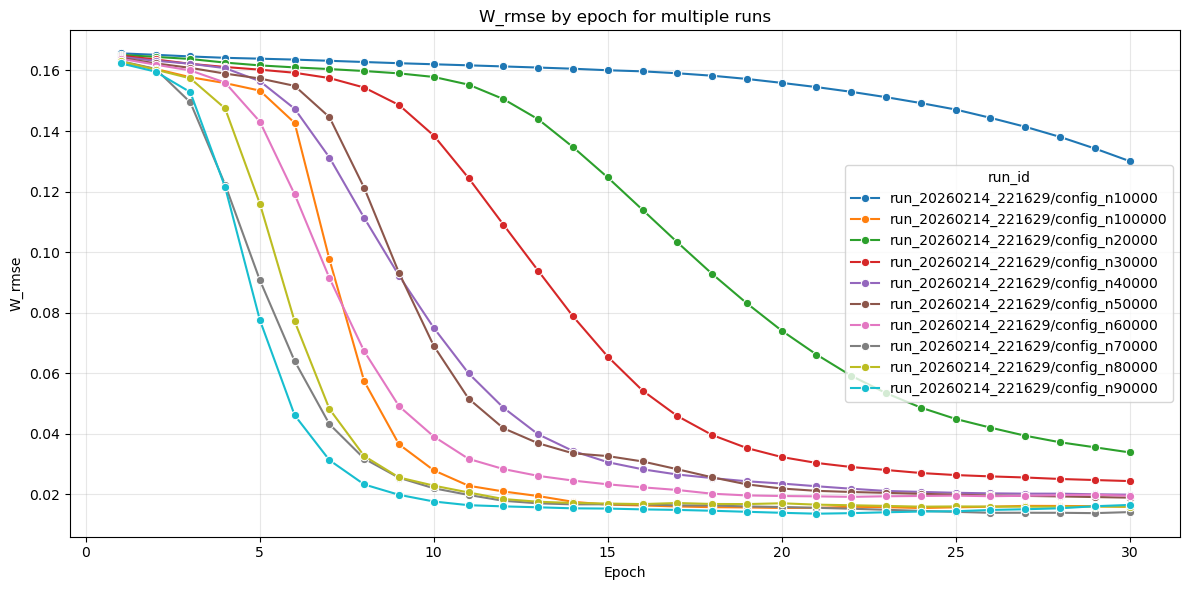

In [ ]:
plot_metric_by_epoch(metric="W_rmse", x_axis="epoch")
plot_metric_by_epoch(metric="W_rmse", x_axis="global_step")